# Machine Learning Group Assginment

## Index
1. Import relvant libraries
2. Data Loading
3. Exploratory Data Analysis
    - Null Values Management
    - Distribution of Variables (Numerical and Categorical)
    - Outlier Management
4. Data Cleaning 
5. Feature Engeneering
6. Correlation Analysis
7. Feature Selection
   - Clusering and Profiling Variables
8. Regression:
    - Model pipeline
    - Training
    - Evaluation
    - Inference
    

# 1. Import relevant labraries

In [100]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn import metrics


# 2. Data Loading 

In [101]:
df = pd.read_excel('Houses for rent in Madrid.xlsx')
df.head()

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


# 3. Exploratory Data Analysis

### Data Cleaning: drop NA values

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   str    
 2   Address       2089 non-null   str    
 3   Number        747 non-null    str    
 4   Area          2085 non-null   str    
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 341.9 KB


Null Values Management

In [103]:
df.isna().sum()/df.shape[0]

Id              0.000000
District        0.000000
Address         0.000000
Number          0.642413
Area            0.001915
Rent            0.000000
Bedrooms        0.042604
Sq.Mt           0.000000
Floor           0.067496
Outer           0.077549
Elevator        0.063667
Penthouse       0.000000
Cottage         0.000000
Duplex          0.000000
Semidetached    0.000000
dtype: float64

Large amount of NaN in the Number column (64%), is not adding any information will be removed.
The other columns that have null values are binary variables, is does not make any sense to input a value and consdering that is only between 6-7% of the total observations those obserations with null values will be removed from the base

In [104]:
df_notnull = df.drop(columns=['Number','Id','Address','Area'])
df_notnull.dropna(inplace=True)
df_notnull.isna().sum()

District        0
Rent            0
Bedrooms        0
Sq.Mt           0
Floor           0
Outer           0
Elevator        0
Penthouse       0
Cottage         0
Duplex          0
Semidetached    0
dtype: int64

### EDA:
Distribution of Variables:
- The Address columns will not be explored beacuse it does not include relevant infromation.
- The Id column will be removed

In [105]:
numeric_cols = ['Rent','Bedrooms','Sq.Mt','Floor']
binary_cols = ['Outer','Elevator','Penthouse','Cottage','Duplex','Semidetached']
categorical_cols =  ['District']

Numeric Columns Analsysis: 

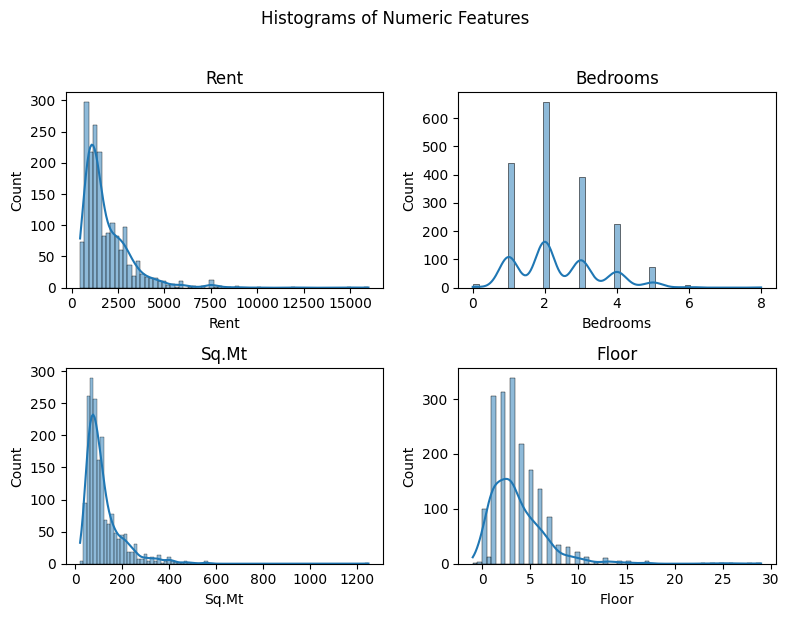

In [106]:
n_num = len(numeric_cols)
if n_num:
    n_cols = 2
    n_rows = int(np.ceil(n_num / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.histplot(df_notnull[col], kde=True, ax=ax, color="#1f77b4")
        ax.set_title(col)
    # Hide extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Histograms of Numeric Features', y=1.02)
    plt.tight_layout()
    plt.show()

Binary Columns Analsysis:

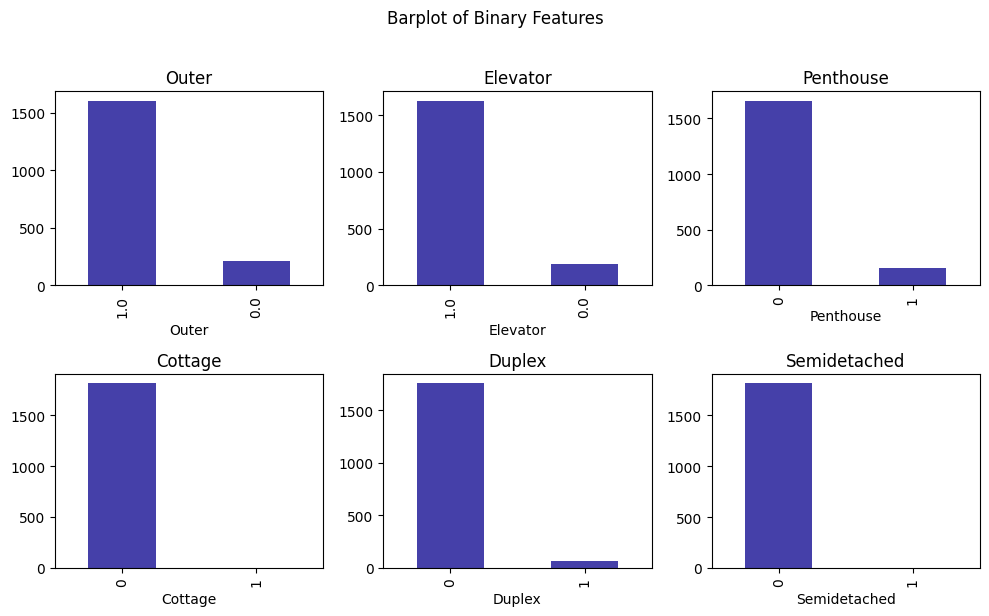

In [107]:
n_num = len(binary_cols)

if n_num:
    # fig, axes = plt.subplots(2, 3, figsize=(4*n_cols, 3*n_rows))
    # axes = axes.flatten()
    # for i, col in enumerate(binary_cols):
    #     ax = axes[i]
    #     sns.barplot(df_notnull[col], ax=ax, color="#1f77b4")
    #     ax.set_title(col)
    #  # Hide extra axes
    # for j in range(i+1, len(axes)):
    #     axes[j].axis('off')
    # fig.suptitle('Barplot of Binary Features', y=1.02)
    # plt.tight_layout()
    # plt.show()
    fig, axes = plt.subplots(2, 3, figsize=(20,12))
    axes = axes.flatten()
    for i,col in enumerate(binary_cols):
        ax = axes[i]
        vc = df_notnull[col].value_counts()
        vc.plot(kind='bar', figsize=(10,6), color="#4540a9",ax=ax)
        ax.set_title(f'{col}')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Barplot of Binary Features', y=1.02)
    plt.tight_layout()
    plt.show()
  

In [108]:
df_notnull['Cottage'].value_counts()

Cottage
0    1816
1       3
Name: count, dtype: int64

In [109]:
df_notnull['Semidetached'].value_counts()

Semidetached
0    1817
1       2
Name: count, dtype: int64

From the count we can conclude that this two columns actually identify some apartments that have very specific caracteristics, so the columns will not be considered as part of the segmentation. 

Categorical Variables:

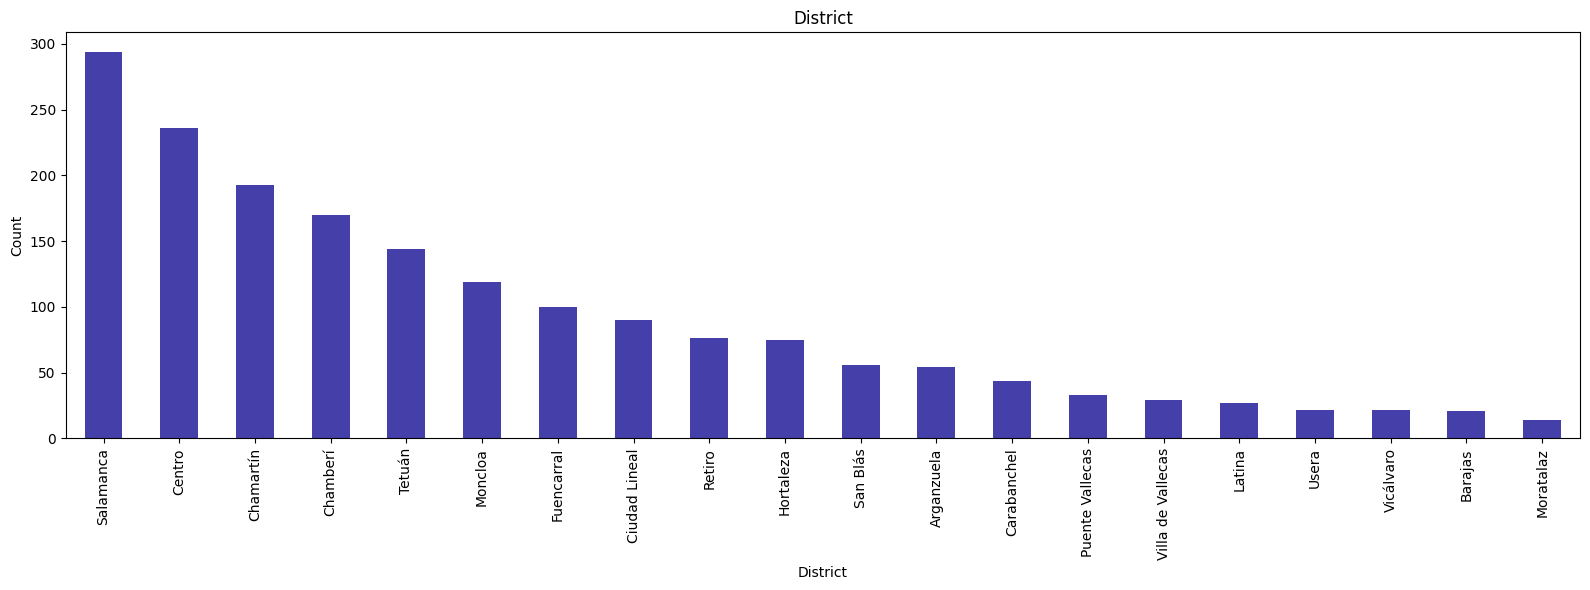

In [110]:
n_num = len(categorical_cols)
if n_num:
    for col in categorical_cols:
        vc = df_notnull[col].value_counts()
        ax = vc.plot(kind='bar', figsize=(16,6), color="#4540a9")
        ax.set_title(f'{col}')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()
  

To simplify the analisis we will consder the district varibale that is a kind of aggrupation of the area variable that has a serveral of values that are not standarized 

### Outlier Identification 

From the hisogram of the floor variables is very evident that there is one or more outliers, to further investigate this we make boxplots for each variable

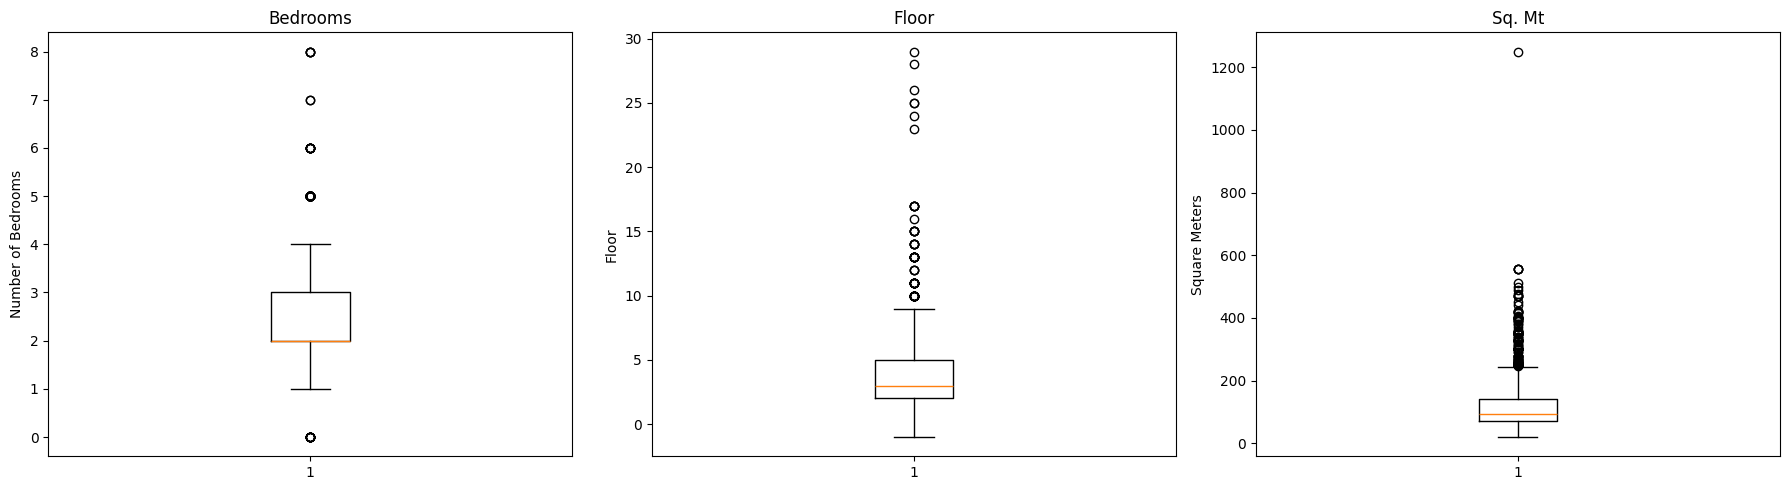

In [111]:
plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
plt.boxplot(df_notnull["Bedrooms"].dropna())
plt.title("Bedrooms")
plt.ylabel("Number of Bedrooms")

plt.subplot(1, 3, 2)
plt.boxplot(df_notnull["Floor"].dropna())
plt.title("Floor")
plt.ylabel("Floor")

plt.subplot(1, 3, 3)
plt.boxplot(df_notnull["Sq.Mt"].dropna()) 
plt.title("Sq. Mt")
plt.ylabel("Square Meters")

plt.tight_layout()
plt.show()

In [112]:
df_notnull.describe().T

,count,mean,std,min,25%,50%,75%,max
Rent,1819.0,1882.699285,1356.233731,450.0,992.5,1400.0,2430.0,16000.0
Bedrooms,1819.0,2.371633,1.183582,0.0,2.0,2.0,3.0,8.0
Sq.Mt,1819.0,118.946124,82.996735,20.0,70.0,92.0,140.0,1250.0
Floor,1819.0,3.624519,3.017691,-1.0,2.0,3.0,5.0,29.0
Outer,1819.0,0.883452,0.320969,0.0,1.0,1.0,1.0,1.0
Elevator,1819.0,0.894997,0.306641,0.0,1.0,1.0,1.0,1.0
Penthouse,1819.0,0.087411,0.282514,0.0,0.0,0.0,0.0,1.0
Cottage,1819.0,0.001649,0.040589,0.0,0.0,0.0,0.0,1.0
Duplex,1819.0,0.034085,0.181497,0.0,0.0,0.0,0.0,1.0
Semidetached,1819.0,0.001100,0.033150,0.0,0.0,0.0,0.0,1.0


Now after removing the Nulls and looking closely at what look like outliers, we dont need to remove other observations, all values seem reasonable.

### Correlation Analysis

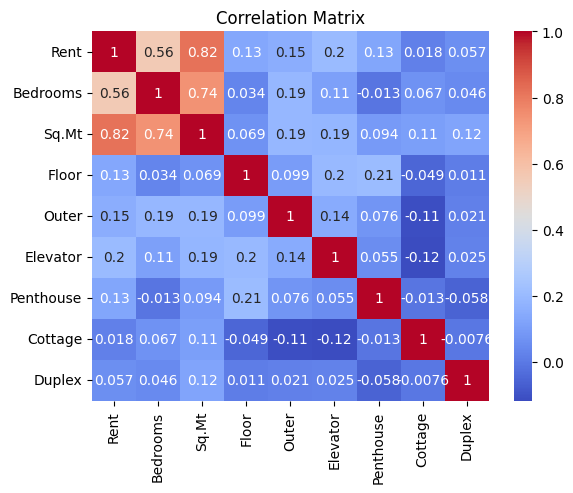

In [113]:
corr = df_notnull[['Rent','Bedrooms','Sq.Mt','Floor','Outer','Elevator','Penthouse','Cottage','Duplex']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   str    
 2   Address       2089 non-null   str    
 3   Number        747 non-null    str    
 4   Area          2085 non-null   str    
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 341.9 KB


# Data Clenaning

In [ ]:
# Should go in the clean_data.py module

df["Bedrooms"] = df["Bedrooms"].fillna(df["Bedrooms"].median())
df["Floor"] = df["Floor"].fillna(0)
df["Outer"] = df["Outer"].fillna(0)
df["Elevator"] = df["Elevator"].fillna(0)
df["Outer"] = df["Outer"].astype(int)
df["Elevator"] = df["Elevator"].astype(int)
df["Bedrooms"] = df["Bedrooms"].astype(int)
df["Floor"] = df["Floor"].astype(int)


df = df.drop(columns=["Id"])
df = df.drop(columns=["Address"])
df = df.drop(columns=["Area"])
df = df.drop(columns=["Number"])


df = df.drop_duplicates()
df.dropna(inplace=True)

# Train, Validate, Predictión split

In [ ]:
# in main.py
#Separating columns depending on their types
binary_cols = [
    col for col in df.columns
    if set(df[col].dropna().unique() )== {0, 1}
]
categorical_cols = [col for col in df.columns if df[col].dtype == 'str']
numerical_cols = [col for col in df.columns if (col not in binary_cols) & (col not in categorical_cols)]
binary_cols,numerical_cols,categorical_cols

(['Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached'],
 ['Rent', 'Bedrooms', 'Sq.Mt', 'Floor'],
 ['District'])

In [117]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline

In [119]:
target = "Rent"
X = df.drop(columns=[target])
y = df[target]

In [120]:
# Separation train,test
train_size = 0.7
test_size = 1- train_size 
# 70% train, 30% validation and test
X, X_test, y, y_test = train_test_split(
X, y, test_size=0.30, random_state=42)
# Split temp into 15% val, 15% test
X, X_val, y, y_val = train_test_split(X, y, test_size=0.30, random_state=42)

# Feature Engineering

In [ ]:
# Feature enginerring -- should go in the train.py module

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()

# If binary is numeric 0/1, pull it out from numeric:
binary_features = [c for c in numeric_features if set(X[c].dropna().unique()) <= {0, 1}]
numeric_features = [c for c in numeric_features if c not in binary_features]
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
    ],
    remainder="drop",
)


C:\Users\ricar\AppData\Local\Temp\ipykernel_56224\545269347.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [ ]:
#Train module -- train.py module
model = LinearRegression()
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
     ("model", model)
])

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [128]:
# Model Results
model = pipeline.named_steps['model']
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by="Coefficient", ascending=False))
print(pipeline.score(X,y))

                            Feature  Coefficient
1                        num__Sq.Mt  1229.419028
17          cat__District_Salamanca   796.524827
16             cat__District_Retiro   580.276505
6              cat__District_Centro   449.274228
8            cat__District_Chamberí   448.146255
7           cat__District_Chamartín   364.815409
13            cat__District_Moncloa   237.752247
19             cat__District_Tetuán   179.521223
23                       bin__Outer   145.603879
25                   bin__Penthouse    80.477003
0                     num__Bedrooms    52.376489
2                        num__Floor    41.974794
24                    bin__Elevator    25.775658
3          cat__District_Arganzuela    14.012842
27                      bin__Duplex    -9.541785
15    cat__District_Puente Vallecas  -141.837154
9       cat__District_Ciudad Lineal  -151.345749
11          cat__District_Hortaleza  -154.906624
28                bin__Semidetached  -204.646370
12             cat__

In [ ]:
# Evaluation of the model -- Should go in the evaluate.py module
y_pred = pipeline.predict(X_val)
r2__val = r2_score(y_val,y_pred) 
r2__val

0.7540084472724058

In [ ]:
#Prediction -- should go in the infer.py module
y_pred = pipeline.predict(X_test)

results = X_test.copy()
results['Rent_predicted'] = y_pred
results['Rent'] = y_test
results['Classification'] = np.where(
    (results['Rent']-results['Rent_predicted'])/results['Rent_predicted'] > 0.05, 'Overpriced',
    np.where(
        (results['Rent']-results['Rent_predicted'])/results['Rent_predicted'] > -0.05, 'Fair priced',
        'Underpriced'
    )
)

results.head()

,District,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Rent_predicted,Rent,Classification
788,Salamanca,3,125,6,1,1,0,0,0,0,2574.575726,1800,Underpriced
803,Salamanca,1,77,5,1,1,0,0,0,0,1925.123990,1500,Underpriced
1757,Chamberí,8,1250,4,1,1,0,0,0,0,15330.923760,15000,Fair priced
1328,Centro,1,55,1,1,1,0,0,0,0,1269.641327,1500,Overpriced
1172,Centro,1,65,1,1,1,0,0,0,0,1384.502782,1600,Overpriced
